### импорты и загрузка данных

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

plt.style.use("seaborn-v0_8")
#ROOT = Path("..").resolve()
#data_path = ROOT / "data" / "Run200_Wave_0_1.txt"
data_path='Run200_Wave_0_1.txt'

# Загрузка сырых данных
dataset = pd.read_csv(
    data_path,
    sep=" ",
    header=None,
    skipinitialspace=True
)

# Удаляем 4 столбца метаданных (0–3) и последний служебный столбец 504
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)

# Переименуем столбцы в 0..499 — это индексы тактов сигнала
dataset.columns = list(range(500))

dataset.shape

(23479, 500)

### просмотр нескольких сигналов

In [4]:
signals = dataset.values.astype(np.float32)  # [N, 500]
N, T = signals.shape
N, T

(23479, 500)

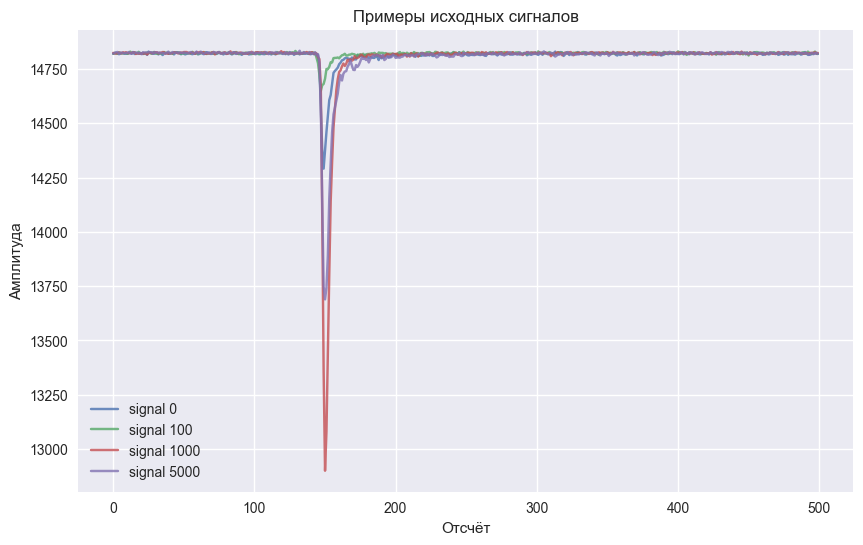

In [5]:
# Несколько примеров сигналов
plt.figure(figsize=(10, 6))
example_indices = [0, 100, 1000, 5000]

for idx in example_indices:
    plt.plot(range(T), signals[idx], alpha=0.8, label=f"signal {idx}")

plt.xlabel("Отсчёт")
plt.ylabel("Амплитуда")
plt.title("Примеры исходных сигналов")
plt.legend()
plt.grid(True)
plt.show()

### анализ baseline и шума

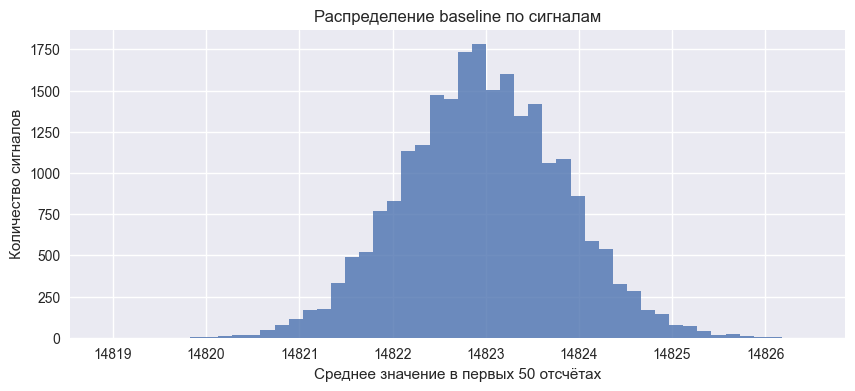

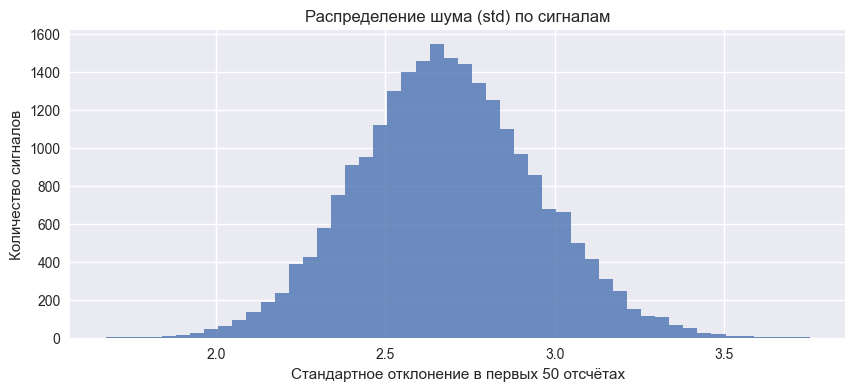

In [6]:
# Берём первые 50 отсчётов как область шума
noise_region = signals[:, :50]

noise_mean = noise_region.mean(axis=1)
noise_std = noise_region.std(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(noise_mean, bins=50, alpha=0.8)
plt.xlabel("Среднее значение в первых 50 отсчётах")
plt.ylabel("Количество сигналов")
plt.title("Распределение baseline по сигналам")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(noise_std, bins=50, alpha=0.8)
plt.xlabel("Стандартное отклонение в первых 50 отсчётах")
plt.ylabel("Количество сигналов")
plt.title("Распределение шума (std) по сигналам")
plt.grid(True)
plt.show()

### простые признаки A и S

In [7]:
# Амплитуда A — максимум по 500 отсчётам
A = signals.max(axis=1)

# Площадь S — интеграл по всем отсчётам
dt = 1.0
S = np.trapz(signals, dx=dt, axis=1)

len(A), len(S)

C:\Users\komar\AppData\Local\Temp\ipykernel_27444\3805677878.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  S = np.trapz(signals, dx=dt, axis=1)


(23479, 23479)

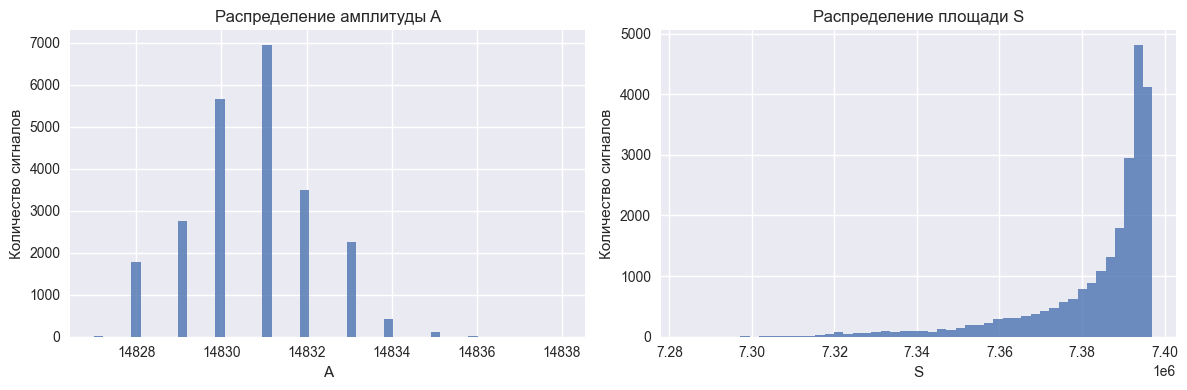

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(A, bins=50, alpha=0.8)
axes[0].set_title("Распределение амплитуды A")
axes[0].set_xlabel("A")
axes[0].set_ylabel("Количество сигналов")
axes[0].grid(True)

axes[1].hist(S, bins=50, alpha=0.8)
axes[1].set_title("Распределение площади S")
axes[1].set_xlabel("S")
axes[1].set_ylabel("Количество сигналов")
axes[1].grid(True)

plt.tight_layout()
plt.show()

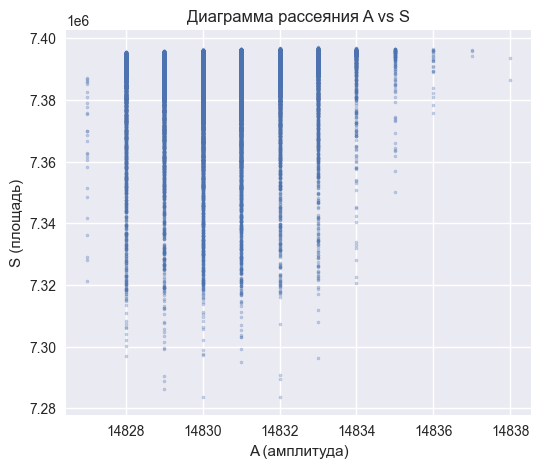

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(A, S, s=5, alpha=0.3)
plt.xlabel("A (амплитуда)")
plt.ylabel("S (площадь)")
plt.title("Диаграмма рассеяния A vs S")
plt.grid(True)
plt.show()

### PSD (long/short) без внешних модулей

In [10]:
# PSD = (long - short) / long
short_len = 40  # длина окна после максимума
PSD = []

for i in range(N):
    sig = signals[i]
    imax = sig.argmax()

    start_short = imax
    end_short = min(T, imax + short_len)

    long_area = np.trapz(sig, dx=dt)
    short_area = np.trapz(sig[start_short:end_short], dx=dt)

    if long_area != 0:
        psd_val = (long_area - short_area) / long_area
    else:
        psd_val = 0.0

    PSD.append(psd_val)

PSD = np.array(PSD, dtype=np.float32)
PSD.shape

C:\Users\komar\AppData\Local\Temp\ipykernel_27444\168298026.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  long_area = np.trapz(sig, dx=dt)
C:\Users\komar\AppData\Local\Temp\ipykernel_27444\168298026.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  short_area = np.trapz(sig[start_short:end_short], dx=dt)


(23479,)

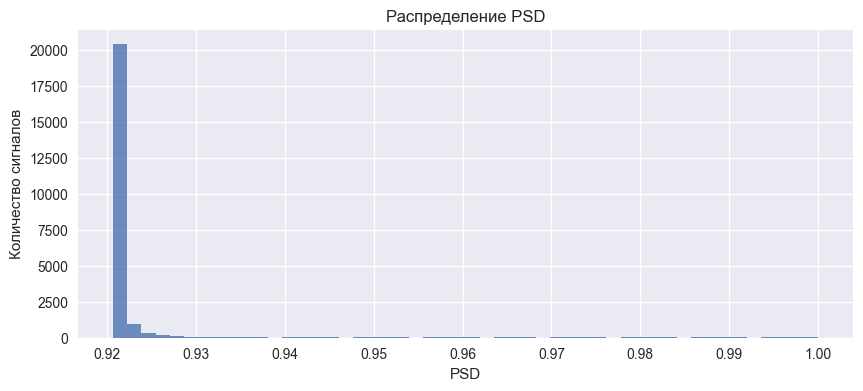

In [11]:
plt.figure(figsize=(10, 4))
plt.hist(PSD, bins=50, alpha=0.8)
plt.xlabel("PSD")
plt.ylabel("Количество сигналов")
plt.title("Распределение PSD")
plt.grid(True)
plt.show()

### очень грубый tau (без curve_fit)

In [12]:
tau_eff = []

k = 3.0  # сколько std над baseline считаем концом сигнала

for i in range(N):
    sig = signals[i]

    # оценка baseline и шума по первым 50 точкам
    base = sig[:50].mean()
    noise = sig[:50].std()

    imax = sig.argmax()
    threshold = base + k * noise

    # ищем индекс, где сигнал опускается ниже порога после максимума
    end_idx = T - 1
    for t in range(imax, T):
        if sig[t] <= threshold:
            end_idx = t
            break

    tau_val = (end_idx - imax) * dt
    tau_eff.append(tau_val)

tau_eff = np.array(tau_eff, dtype=np.float32)
tau_eff.shape

(23479,)

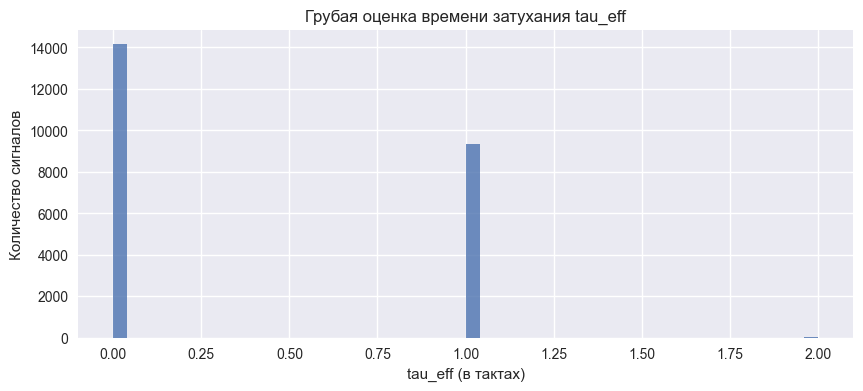

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(tau_eff, bins=50, alpha=0.8)
plt.xlabel("tau_eff (в тактах)")
plt.ylabel("Количество сигналов")
plt.title("Грубая оценка времени затухания tau_eff")
plt.grid(True)
plt.show()

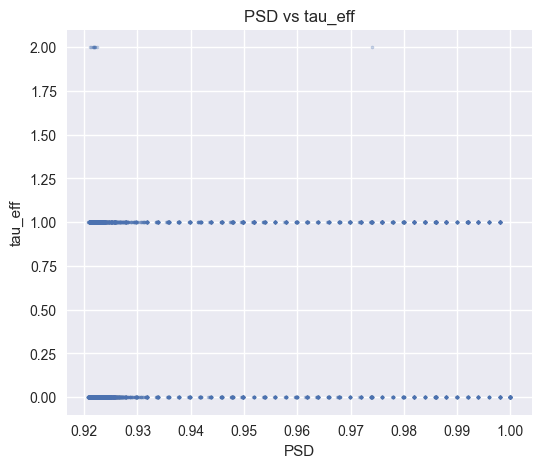

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(PSD, tau_eff, s=5, alpha=0.3)
plt.xlabel("PSD")
plt.ylabel("tau_eff")
plt.title("PSD vs tau_eff")
plt.grid(True)
plt.show()

### мини-PCA для визуализации (по A, S, PSD, tau_eff)

In [15]:
from sklearn.decomposition import PCA

# Собираем матрицу простых признаков для EDA (без зависимостей от src)
X = np.vstack([A, S, PSD, tau_eff]).T  # [N, 4]

# Нормировка
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-9
X_norm = (X - mean) / std

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_norm)

X_pca.shape

(23479, 2)

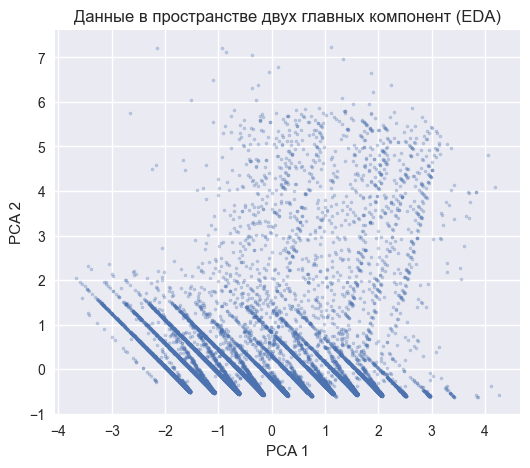

In [16]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.3)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Данные в пространстве двух главных компонент (EDA)")
plt.grid(True)
plt.show()

### Вывод

Структура сигналов.
Сырые сигналы имеют чётко выраженный максимум и хвост затухания, а начальные отсчёты до импульса описывают шум вокруг некоторой базовой линии. Это позволяет надёжно оценивать baseline (среднее первых 50 точек) и уровень шума (стандартное отклонение), а сам сигнал естественно выделять как участок от максимума до возвращения к «нулевой» линии.

Шум и baseline.
Распределения средних и стандартных отклонений по первым 50 отсчётам узкие и одногорбые. Это говорит о том, что шум детектора стабилен от события к событию, а варьируются в основном именно формы и амплитуды полезных импульсов. Такой характер шума позволяет использовать пороги вида baseline + k·σ для автоматического выделения конца сигнала.

Амплитуда и площадь (A, S).
Гистограммы амплитуды и площади под сигналом показывают протяжённые хвосты и намёки на несколько характерных диапазонов. На диаграмме рассеяния A vs S заметно, что точки ложатся на вытянутую облако, близкое к линейной зависимости, но с разной плотностью в различных областях. Это согласуется с тем, что амплитуда и площадь связаны с поглощённой энергией частицы, но по разным типам частиц коэффициенты пропорциональности различаются.

Форма сигнала: PSD и tau_eff.
Распределение PSD и грубой оценки времени затухания tau_eff показывает, что в данных присутствуют по крайней мере две группы сигналов: одни имеют более «длинный» хвост (больший вклад хвостовой части, больший tau_eff), другие — более «острые», с быстрым спадом. При рассмотрении scatter-графика PSD vs tau_eff видно, что точки образуют структуры, похожие на два облака, что является прямой индикацией наличия нескольких типов импульсов.

Понижение размерности (PCA).
При переходе к пространству первых двух главных компонент по признакам A, S, PSD и tau_eff данные образуют компактное облако, внутри которого прослеживаются области повышенной плотности. Это означает, что выбранные признаки действительно концентрируют основную вариативность данных и позволяют упростить задачу кластеризации до двумерной постановки без заметной потери информации.

В совокупности EDA показывает, что:

шум стабилен и управляем;

сигналы отличаются не только «силой» (A, S), но и формой (PSD, tau);

физически мотивированные признаки хорошо выделяют структуру данных и дают естественную базу для последующей кластеризации.